<a href="https://colab.research.google.com/github/Young-yrx/guizhou-landslide/blob/main/guizhou.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#贵州水城滑坡易发性评价
##逻辑回归、XGBoost、随机森林（K折交叉验证 + 诊断子图 + SHAP解释）

###特征列表（共8个）：

####地形因子：
    Curvatu, Aspect, Slope, Reclass, PTC, TWI

####降雨因子：
     rain_3day, rain_7day

##库文件

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc,
                             precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb
import rasterio
import warnings
warnings.filterwarnings('ignore')

# SHAP 解释库
import shap
shap.initjs()  # 初始化JavaScript可视化（用于瀑布图等交互图）

##读取数据文件

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/date/landslide_real.xls', sheet_name='RasterT_RasterC1')

# 特征工程：计算累积降雨量
df['rain_3day'] = df['rain20190721'] + df['rain20190722'] + df['rain20190723']
df['rain_7day'] = df['rain20190716'] + df['rain20190720'] + df['rain20190721'] + df['rain20190722'] + df['rain20190723']

# 定义最终用于建模的特征列（8个）
feature_cols = [
    'Curvatu_ASTG1',
    'Aspect_ASTGT1',
    'Slope_ASTGTM1',
    'Reclass_ASTG1',
    'PTC',
    'TWI',
    'rain_3day',
    'rain_7day'
]

# 提取特征矩阵 X 和标签 y
X = df[feature_cols].copy()
y = df['grid_code'].values  # 标签列名为 'grid_code'

print(f"总样本数: {len(X)}，滑坡样本: {int(y.sum())}，非滑坡样本: {len(y) - int(y.sum())}")
print(f"特征列名: {X.columns.tolist()}")
print(f"标签分布:\n{pd.Series(y).value_counts()}")

##处理缺失值（填充中位数）

In [ ]:
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print("缺失值已使用中位数填充。")

##划分训练集与测试集（用于最终独立测试）

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"训练集: {len(X_train)}，测试集: {len(X_test)}")

##定义三个模型

In [ ]:
def get_models():
    """返回三个模型的字典"""
    models = {}

    # 逻辑回归（带标准化）
    lr_pipeline = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            solver='liblinear',
            random_state=42
        )
    )
    models['Logistic Regression'] = lr_pipeline

    # XGBoost
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,        # 从5改成3
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5, # 新增：限制过拟合
    random_state=42,
    eval_metric='logloss'
    )
    models['XGBoost'] = xgb_model

    # 随机森林
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,       # 从10改成5
        min_samples_leaf=5, # 新增：叶节点最少5个样本
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    models['Random Forest'] = rf_model

    return models

models = get_models()

##K 折交叉验证评估（K=5）

In [ ]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 存储每个模型的交叉验证结果
cv_results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"正在对 {name} 进行 5 折交叉验证...")
    print('='*60)

    # 交叉验证预测概率（用于计算AUC和绘制ROC）
    y_proba_cv = cross_val_predict(model, X_train, y_train, cv=kfold, method='predict_proba')[:, 1]
    y_pred_cv = (y_proba_cv > 0.5).astype(int)

    # 计算各项指标
    acc_cv = accuracy_score(y_train, y_pred_cv)
    prec_cv = precision_score(y_train, y_pred_cv)
    rec_cv = recall_score(y_train, y_pred_cv)
    f1_cv = f1_score(y_train, y_pred_cv)
    auc_cv = roc_auc_score(y_train, y_proba_cv)

    # 计算各折的AUC以评估稳定性
    auc_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='roc_auc')

    cv_results[name] = {
        'Accuracy': acc_cv,
        'Precision': prec_cv,
        'Recall': rec_cv,
        'F1-score': f1_cv,
        'AUC': auc_cv,
        'AUC_per_fold': auc_scores,
        'AUC_mean': auc_scores.mean(),
        'AUC_std': auc_scores.std()
    }

    print(f"交叉验证结果（训练集，K=5）:")
    print(f"  Accuracy : {acc_cv:.4f}")
    print(f"  Precision: {prec_cv:.4f}")
    print(f"  Recall   : {rec_cv:.4f}")
    print(f"  F1-score : {f1_cv:.4f}")
    print(f"  AUC      : {auc_cv:.4f} (各折: {np.round(auc_scores, 4)})")
    print(f"  AUC Mean ± Std: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")

##交叉验证 ROC 曲线对比（基于训练集CV预测概率）

In [ ]:
plt.figure(figsize=(8, 6))
for name in models.keys():
    y_proba = cross_val_predict(models[name], X_train, y_train, cv=kfold, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y_train, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (5-Fold Cross-Validation on Training Set)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##交叉验证指标汇总条形图

In [ ]:
metrics_df = pd.DataFrame(cv_results).T[['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']]
metrics_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Metrics (5-Fold CV on Training Set)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 打印详细对比表
print("\n" + "="*60)
print("模型性能对比表（K=5交叉验证）")
print("="*60)
print(metrics_df.to_string())

##使用全部训练数据训练最终模型，并在独立测试集上评估

In [ ]:
print("\n" + "="*60)
print("在全部训练数据上重新训练模型，并在独立测试集上评估...")
print("="*60)

final_models = {}
test_results = {}
test_probs = {}  # 保存测试集预测概率用于诊断图

for name, model in models.items():
    # 在完整训练集上训练
    model.fit(X_train, y_train)
    final_models[name] = model

    # 在测试集上评估
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    test_probs[name] = y_prob

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)

    test_results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'AUC': auc_score
    }

    print(f"\n{name} 在独立测试集上的表现:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print(f"  AUC      : {auc_score:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Non-landslide', 'Landslide']))

##独立测试集 ROC 曲线对比

In [ ]:
plt.figure(figsize=(8, 6))
for name, model in final_models.items():
    y_prob = test_probs[name]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Independent Test Set)')
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

##混淆矩阵对比（测试集）

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (name, model) in enumerate(final_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non', 'Landslide'], yticklabels=['Non', 'Landslide'], ax=axes[idx])
    axes[idx].set_title(f'{name} - Confusion Matrix')
    axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('Actual')
plt.tight_layout(); plt.show()

##诊断子图（为每个模型单独绘制）

In [ ]:
for name in final_models.keys():
    y_prob = test_probs[name]
    residual = y_test - y_prob
    probs_landslide = y_prob[y_test == 1]
    probs_non = y_prob[y_test == 0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].scatter(y_test, y_prob, alpha=0.6, color='blue')
    axes[0].plot([0, 1], [0, 1], 'r--')
    axes[0].set_xlabel('Actual Label'); axes[0].set_ylabel('Predicted Probability')
    axes[0].set_title(f'{name}: Predicted vs Actual'); axes[0].grid(True)

    sns.histplot(residual, kde=True, color='blue', ax=axes[1])
    axes[1].set_title(f'{name}: Residuals')
    axes[1].set_xlabel('Residual (Actual - Predicted Probability)')

    axes[2].hist(probs_non, bins=20, alpha=0.6, label='Non-landslide', color='blue')
    axes[2].hist(probs_landslide, bins=20, alpha=0.6, label='Landslide', color='red')
    axes[2].set_xlabel('Predicted Probability'); axes[2].set_ylabel('Frequency')
    axes[2].set_title(f'{name}: Probability Distribution by Class')
    axes[2].legend()
    plt.tight_layout(); plt.show()

##SHAP 模型解释（稳定版，兼容三维数组）

In [ ]:
print("\n" + "="*60)
print("正在进行 SHAP 模型解释分析...")
print("="*60)

background = shap.sample(X_train, 100, random_state=42)
shap_values_dict = {}

for name, model in final_models.items():
    print(f"\n正在计算 {name} 的 SHAP 值...")

    if name == 'Logistic Regression':
        X_test_transformed = model.named_steps['standardscaler'].transform(X_test)
        background_transformed = model.named_steps['standardscaler'].transform(background)
        explainer = shap.LinearExplainer(
            model.named_steps['logisticregression'],
            background_transformed
        )
        shap_values = explainer.shap_values(X_test_transformed)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
    else:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            shap_values = shap_values[:, :, 1]

    if shap_values.ndim != 2:
        raise ValueError(f"SHAP 值维度异常: {shap_values.shape}，预期为 2 维")

    shap_values_dict[name] = shap_values

    # SHAP 摘要图
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
    plt.title(f'{name} - SHAP Summary Plot')
    plt.tight_layout()
    plt.show()

    # SHAP 特征重要性条形图
    shap_importance = np.abs(shap_values).mean(axis=0).flatten()
    shap_importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'SHAP Importance': shap_importance
    })
    shap_importance_df = shap_importance_df.sort_values('SHAP Importance', ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(shap_importance_df['Feature'], shap_importance_df['SHAP Importance'], color='teal')
    plt.xlabel('Mean |SHAP Value|')
    plt.title(f'{name} - SHAP Feature Importance')
    plt.tight_layout()
    plt.show()

##多模型 SHAP 重要性对比

In [ ]:
shap_compare = pd.DataFrame({
    name: np.abs(shap_values_dict[name]).mean(axis=0).flatten()
    for name in final_models.keys()
}, index=feature_cols)

shap_compare.plot(kind='bar', figsize=(14, 6))
plt.title('SHAP Feature Importance Comparison')
plt.ylabel('Mean |SHAP Value|')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

##模型自带特征重要性对比

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for idx, (name, model) in enumerate(final_models.items()):
    if name == 'Logistic Regression':
        coef = model.named_steps['logisticregression'].coef_[0]
        importance = np.abs(coef)
    else:
        importance = model.feature_importances_
    fi_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importance})
    fi_df = fi_df.sort_values('Importance', ascending=True)
    axes[idx].barh(fi_df['Feature'], fi_df['Importance'], color='teal')
    axes[idx].set_title(f'{name} - Feature Importance')
    axes[idx].set_xlabel('Importance')
plt.tight_layout()
plt.show()

##研究区栅格预测（需准备8个栅格文件）

In [ ]:
raster_files = [
    '/content/drive/MyDrive/Colab Notebooks/date/Curvatu_ASTG1.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/Aspect_ASTGT1.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/Slope_ASTGTM1.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/Reclass_ASTG1.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/PTC.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/TWI.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/rain_3day.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/rain_7day.tif'

]

if len(raster_files) != len(feature_cols):
    raise ValueError(f"栅格文件数量 ({len(raster_files)}) 与特征数量 ({len(feature_cols)}) 不一致！")

with rasterio.open(raster_files[0]) as src:
    profile = src.profile
    ref_shape = (src.height, src.width)

feature_stack = np.zeros((ref_shape[0], ref_shape[1], len(raster_files)), dtype=np.float32)
for i, fpath in enumerate(raster_files):
    with rasterio.open(fpath) as src:
        if (src.height, src.width) != ref_shape:
            raise ValueError(f"栅格尺寸不一致！参考: {raster_files[0]}, 当前: {fpath}")
        feature_stack[:, :, i] = src.read(1)

feature_stack[feature_stack < -9990] = np.nan
rows, cols, bands = feature_stack.shape
feature_2d = feature_stack.reshape(-1, bands)
valid_mask = ~np.isnan(feature_2d).any(axis=1)
valid_features = feature_2d[valid_mask]

if valid_features.shape[0] > 0:
    valid_features = imputer.transform(valid_features)
else:
    raise ValueError("没有有效像素。")

print(f"总像素数: {rows*cols}，有效像素数: {valid_features.shape[0]}")

prob_maps = {}
for name, model in final_models.items():
    print(f"正在使用 {name} 进行栅格预测...")
    pred_prob = model.predict_proba(valid_features)[:, 1]
    prob_map = np.full(rows * cols, np.nan, dtype=np.float32)
    prob_map[valid_mask] = pred_prob
    prob_map = prob_map.reshape(rows, cols)
    prob_maps[name] = prob_map

    output_file = f'landslide_susceptibility_{name.replace(" ", "_")}.tif'
    out_profile = profile.copy()
    out_profile.update(dtype=rasterio.float32, count=1, compress='lzw', nodata=np.nan)
    with rasterio.open(output_file, 'w', **out_profile) as dst:
        dst.write(prob_map, 1)
    print(f"  已保存至: {output_file}")

##绘制三模型易发性图对比

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, (name, prob_map) in enumerate(prob_maps.items()):
    im = axes[idx].imshow(prob_map, cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[idx].set_title(f'{name}')
    axes[idx].axis('off')
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Landslide Probability')
plt.suptitle('Landslide Susceptibility Maps Comparison', fontsize=14)
plt.show()

print("\n✅ 所有分析完成！")

##绘制西南地区易发性评价图

In [ ]:
raster_files_sichuan = [
    '/path/to/sichuan/curvature.tif',      # 曲率
    '/path/to/sichuan/aspect.tif',         # 坡向
    '/path/to/sichuan/slope.tif',          # 坡度
    '/path/to/sichuan/reclass.tif',        # 重分类
    '/path/to/sichuan/ptc.tif',            # PTC
    '/path/to/sichuan/twi.tif',            # TWI
    '/path/to/sichuan/rain_3day.tif',      # 3天累积降雨
    '/path/to/sichuan/rain_7day.tif'       # 7天累积降雨
]

# 检查栅格文件数量是否与特征数量一致
if len(raster_files_sichuan) != len(feature_cols):
    raise ValueError(f"栅格文件数量 ({len(raster_files_sichuan)}) 与特征数量 ({len(feature_cols)}) 不一致！")

# 打开第一个栅格获取元数据（地理变换、坐标系、尺寸等）
with rasterio.open(raster_files_sichuan[0]) as src:
    profile = src.profile
    ref_shape = (src.height, src.width)

# 创建特征堆栈（带尺寸检查）
feature_stack = np.zeros((ref_shape[0], ref_shape[1], len(raster_files_sichuan)), dtype=np.float32)
for i, fpath in enumerate(raster_files_sichuan):
    with rasterio.open(fpath) as src:
        if (src.height, src.width) != ref_shape:
            raise ValueError(f"栅格尺寸不一致！参考: {raster_files_sichuan[0]}, 当前: {fpath}")
        feature_stack[:, :, i] = src.read(1)

# 处理 NoData 值（假设无效值小于 -9990，根据实际情况调整）
feature_stack[feature_stack < -9990] = np.nan
rows, cols, bands = feature_stack.shape
feature_2d = feature_stack.reshape(-1, bands)
valid_mask = ~np.isnan(feature_2d).any(axis=1)
valid_features = feature_2d[valid_mask]

if valid_features.shape[0] > 0:
    # 使用训练集拟合的 imputer 填充缺失值（必须与训练时一致）
    valid_features = imputer.transform(valid_features)
else:
    raise ValueError("没有有效像素，请检查栅格数据范围和 NoData 值设置。")

print(f"西南地区总像素数: {rows*cols}，有效像素数: {valid_features.shape[0]}")

# 对每个模型进行预测并保存 GeoTIFF
prob_maps = {}
for name, model in final_models.items():
    print(f"正在使用 {name} 进行西南地区栅格预测...")
    pred_prob = model.predict_proba(valid_features)[:, 1]
    prob_map = np.full(rows * cols, np.nan, dtype=np.float32)
    prob_map[valid_mask] = pred_prob
    prob_map = prob_map.reshape(rows, cols)
    prob_maps[name] = prob_map

    output_file = f'sichuan_landslide_susceptibility_{name.replace(" ", "_")}.tif'
    out_profile = profile.copy()
    out_profile.update(dtype=rasterio.float32, count=1, compress='lzw', nodata=np.nan)
    with rasterio.open(output_file, 'w', **out_profile) as dst:
        dst.write(prob_map, 1)
    print(f"  已保存至: {output_file}")

# 绘制三模型易发性图对比
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, (name, prob_map) in enumerate(prob_maps.items()):
    im = axes[idx].imshow(prob_map, cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[idx].set_title(f'{name}')
    axes[idx].axis('off')
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Landslide Probability')
plt.suptitle('Sichuan Province Landslide Susceptibility Maps Comparison', fontsize=14)
plt.show()

print("\n✅ 西南地区易发性制图完成！")

#代码汇总

总样本数: 1118，滑坡样本: 559，非滑坡样本: 559
特征列名: ['Curvatu_ASTG1', 'Aspect_ASTGT1', 'Slope_ASTGTM1', 'Reclass_ASTG1', 'PTC', 'TWI', 'rain_3day', 'rain_7day']
标签分布:
0    559
1    559
Name: count, dtype: int64
缺失值已使用中位数填充。
训练集: 894，测试集: 224

正在对 Logistic Regression 进行 5 折交叉验证...
交叉验证结果（训练集，K=5）:
  Accuracy : 0.8154
  Precision: 0.7889
  Recall   : 0.8613
  F1-score : 0.8235
  AUC      : 0.8607 (各折: [0.8483 0.8488 0.8744 0.8497 0.8904])
  AUC Mean ± Std: 0.8623 ± 0.0172

正在对 XGBoost 进行 5 折交叉验证...
交叉验证结果（训练集，K=5）:
  Accuracy : 0.9530
  Precision: 0.9810
  Recall   : 0.9239
  F1-score : 0.9516
  AUC      : 0.9914 (各折: [0.9815 0.9916 0.9984 0.9905 0.9941])
  AUC Mean ± Std: 0.9912 ± 0.0056

正在对 Random Forest 进行 5 折交叉验证...
交叉验证结果（训练集，K=5）:
  Accuracy : 0.9340
  Precision: 0.9470
  Recall   : 0.9195
  F1-score : 0.9330
  AUC      : 0.9883 (各折: [0.9821 0.9844 0.9961 0.9869 0.989 ])
  AUC Mean ± Std: 0.9877 ± 0.0048


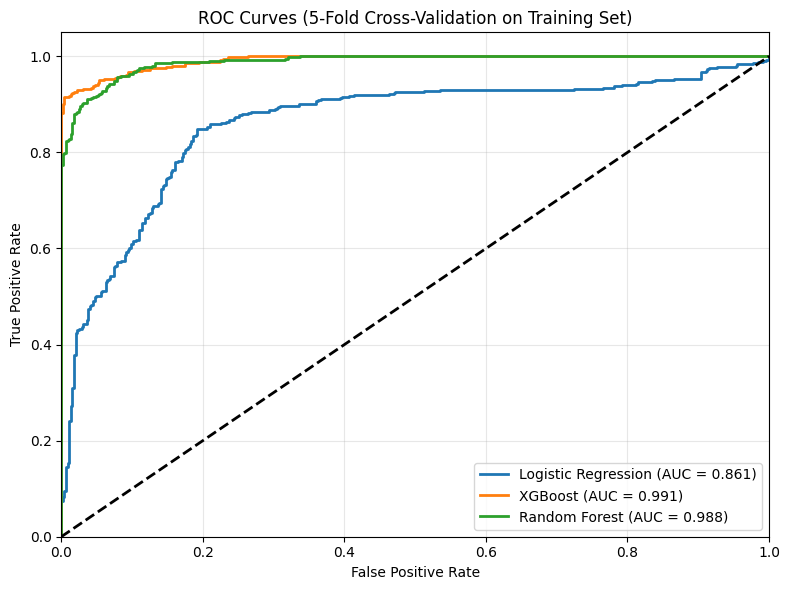

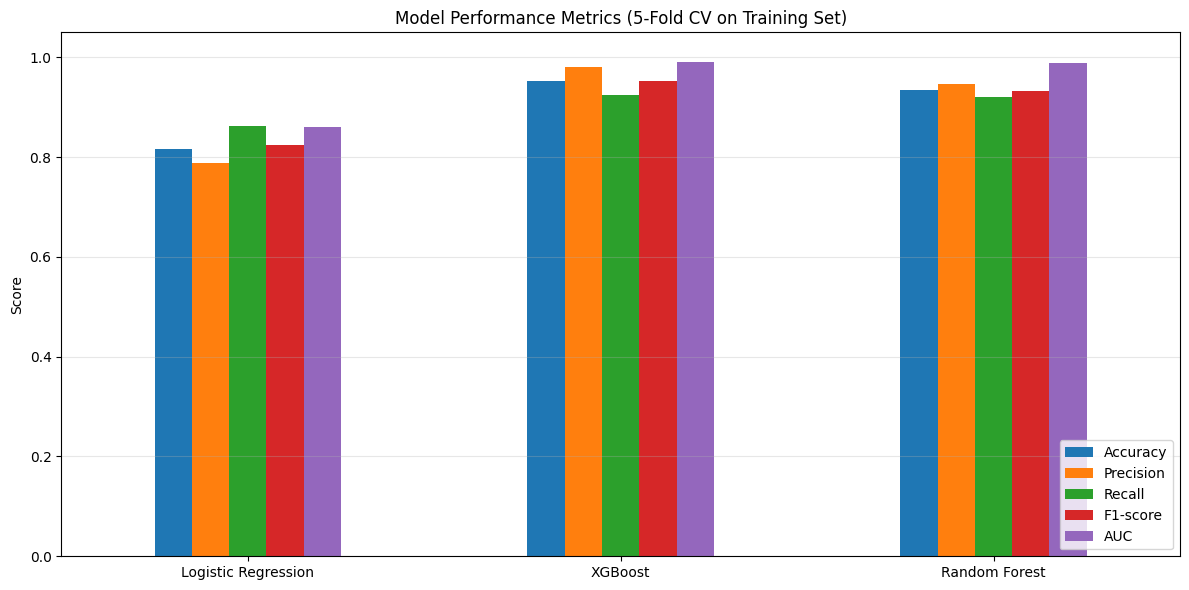


模型性能对比表（K=5交叉验证）
                     Accuracy Precision    Recall  F1-score       AUC
Logistic Regression  0.815436  0.788934  0.861298  0.823529  0.860692
XGBoost               0.95302  0.980998  0.923937  0.951613  0.991417
Random Forest        0.934004  0.947005  0.919463  0.933031  0.988289

在全部训练数据上重新训练模型，并在独立测试集上评估...

Logistic Regression 在独立测试集上的表现:
  Accuracy : 0.8259
  Precision: 0.7829
  Recall   : 0.9018
  F1-score : 0.8382
  AUC      : 0.8987
               precision    recall  f1-score   support

Non-landslide       0.88      0.75      0.81       112
    Landslide       0.78      0.90      0.84       112

     accuracy                           0.83       224
    macro avg       0.83      0.83      0.82       224
 weighted avg       0.83      0.83      0.82       224


XGBoost 在独立测试集上的表现:
  Accuracy : 0.9777
  Precision: 0.9908
  Recall   : 0.9643
  F1-score : 0.9774
  AUC      : 0.9994
               precision    recall  f1-score   support

Non-landslide       0.97     

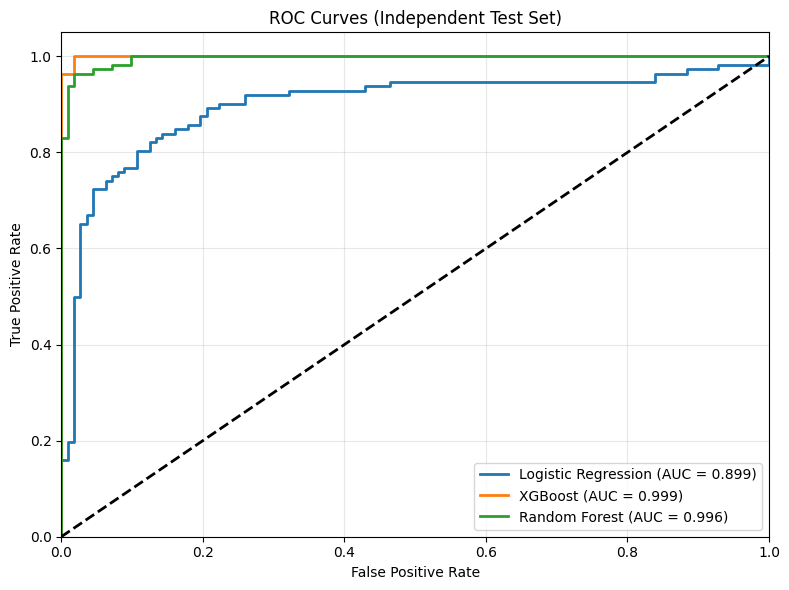

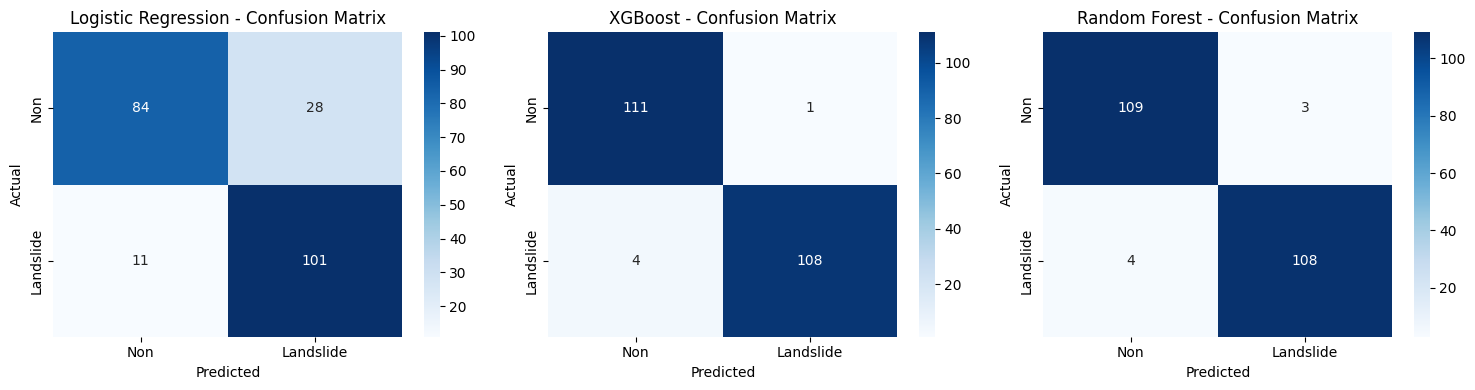

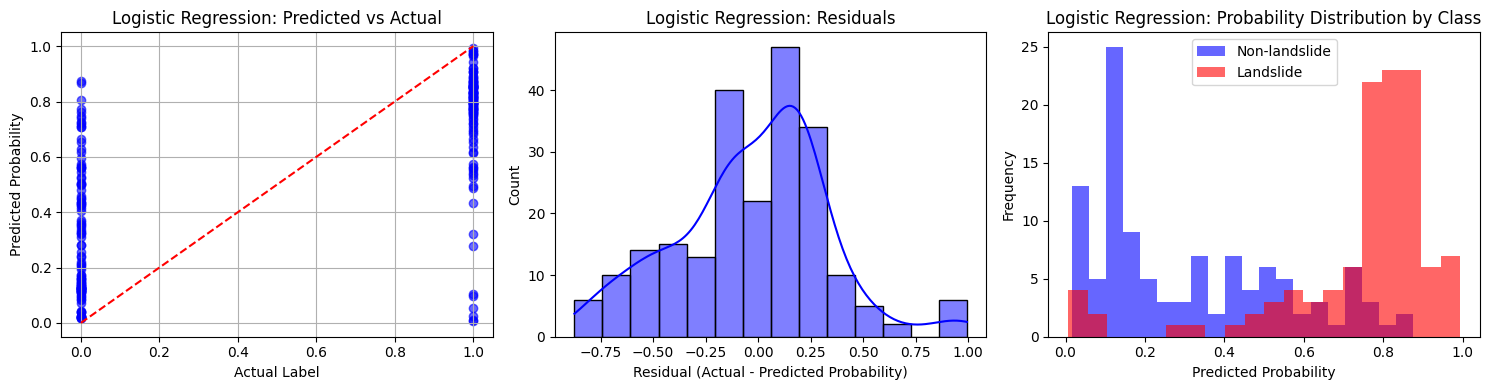

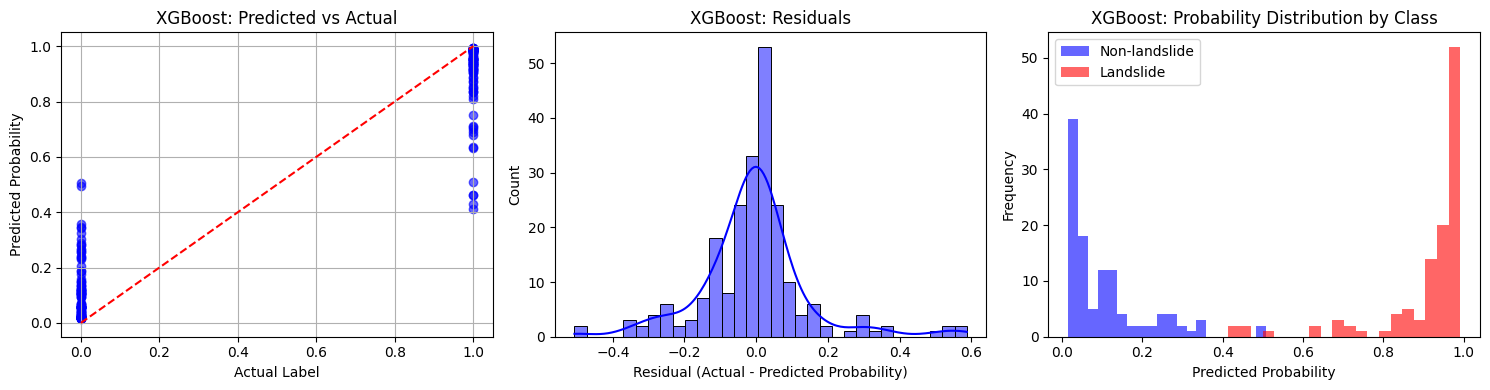

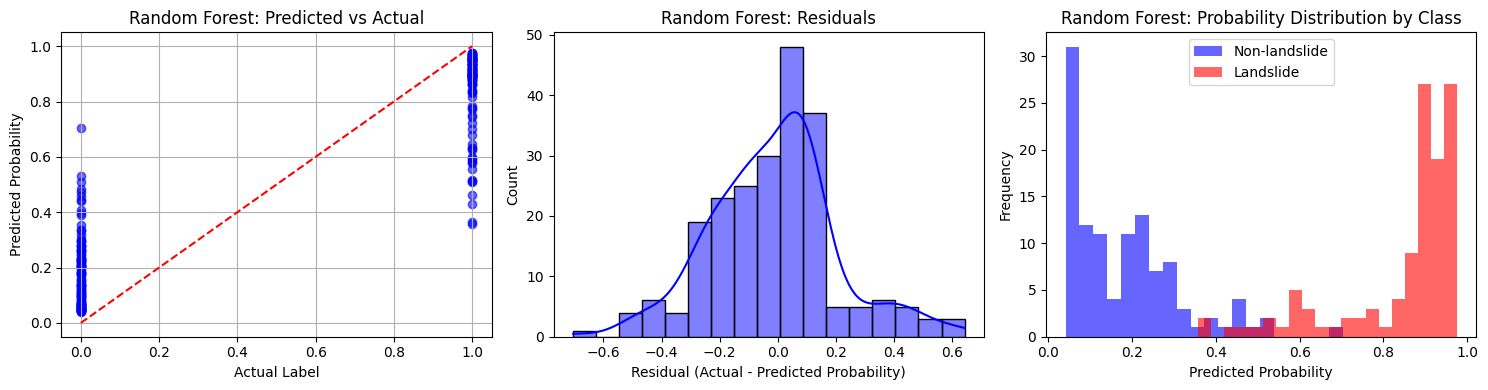


正在进行 SHAP 模型解释分析...

正在计算 Logistic Regression 的 SHAP 值...


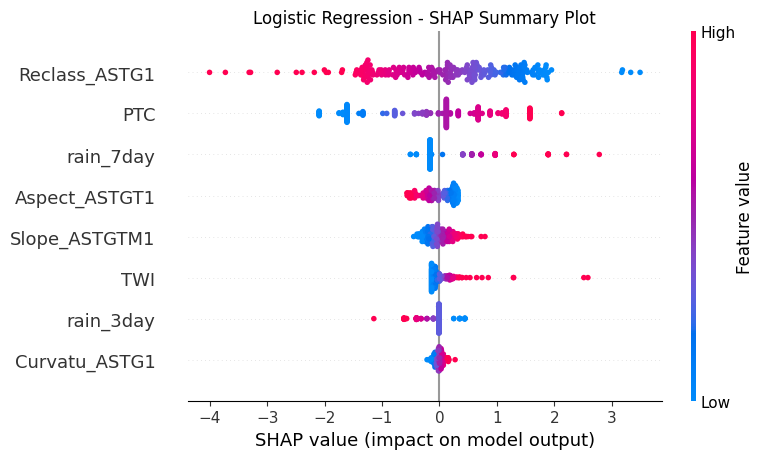

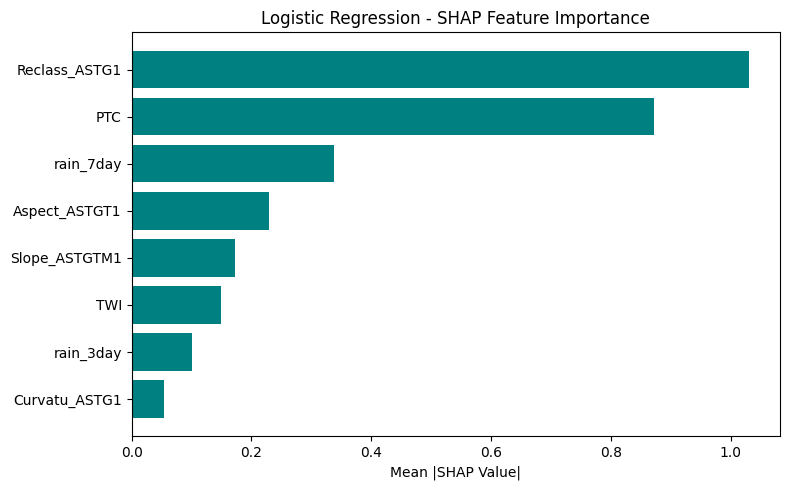


正在计算 XGBoost 的 SHAP 值...


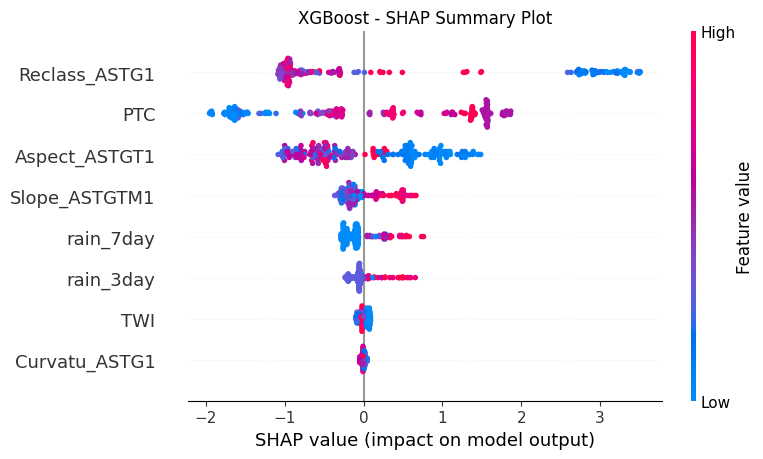

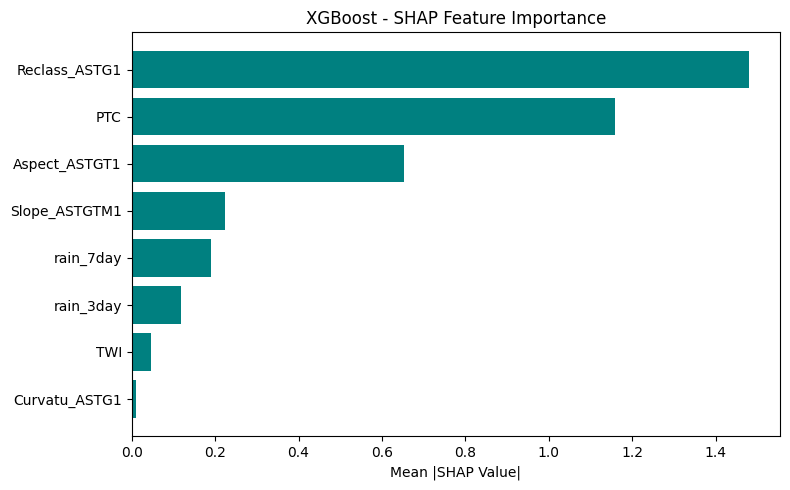


正在计算 Random Forest 的 SHAP 值...


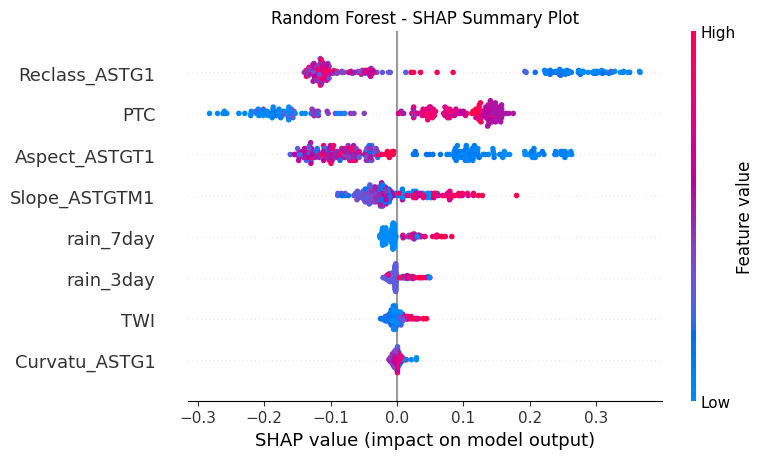

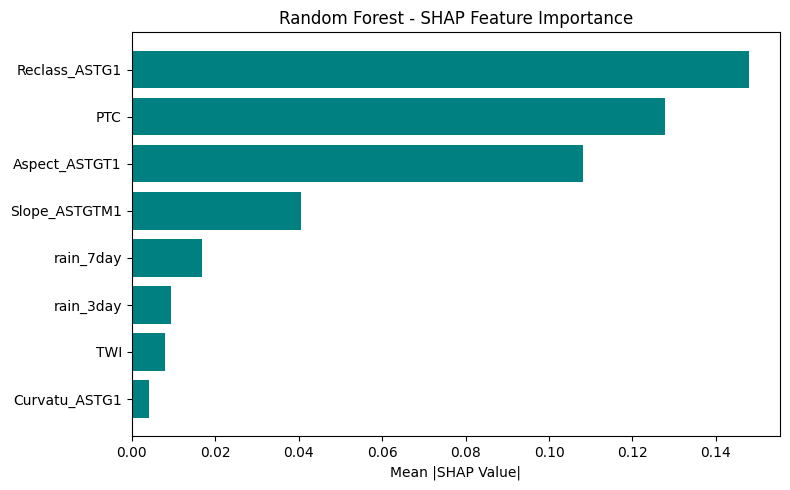

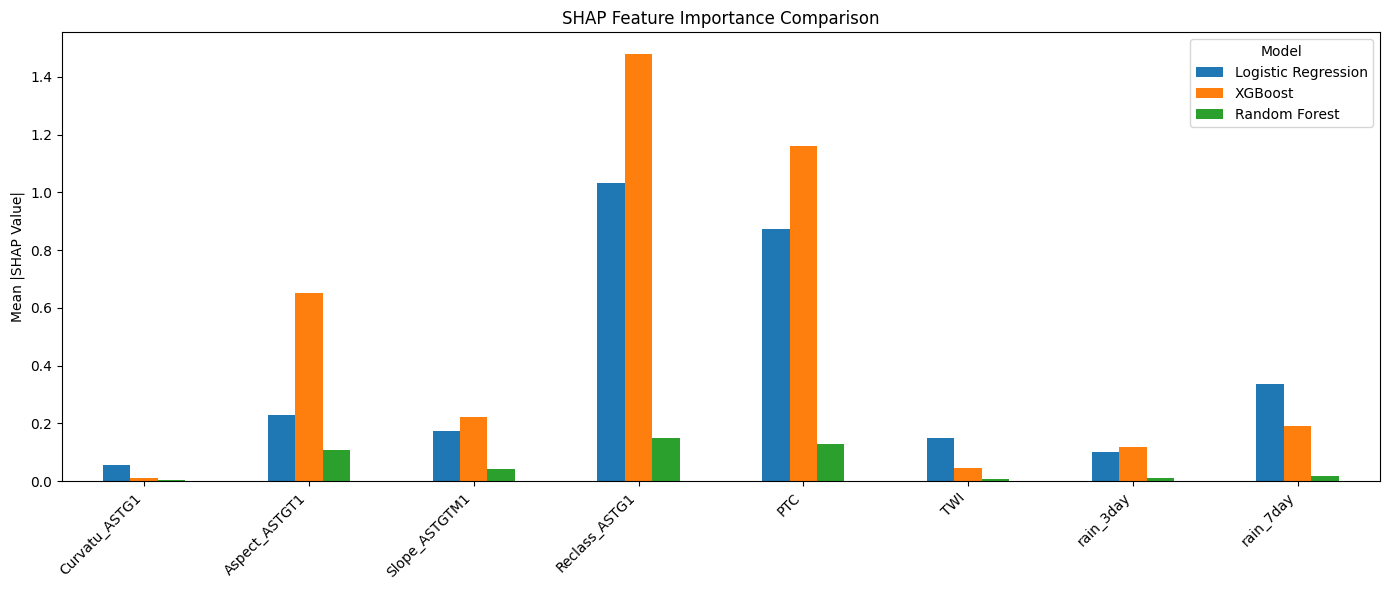

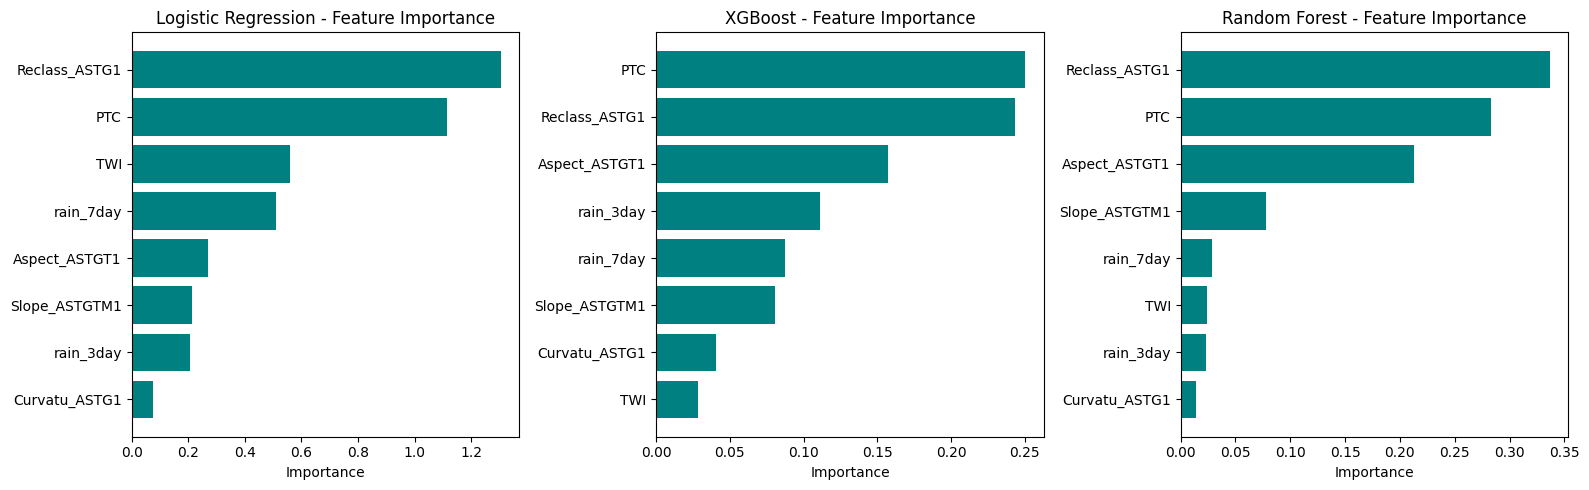

总像素数: 12967201，有效像素数: 6676231
正在使用 Logistic Regression 进行栅格预测...
  已保存至: landslide_susceptibility_Logistic_Regression.tif
正在使用 XGBoost 进行栅格预测...
  已保存至: landslide_susceptibility_XGBoost.tif
正在使用 Random Forest 进行栅格预测...
  已保存至: landslide_susceptibility_Random_Forest.tif


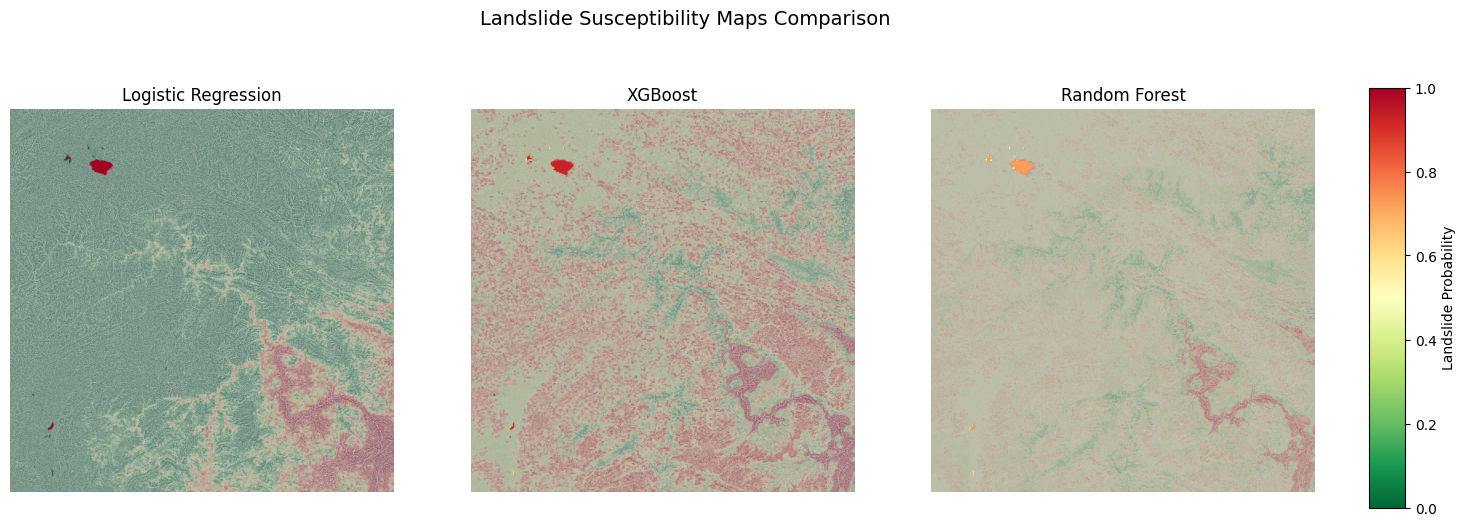


✅ 所有分析完成！


In [1]:
# -*- coding: utf-8 -*-
"""
贵州水城滑坡易发性评价 —— 逻辑回归、XGBoost、随机森林对比
（K折交叉验证 + 诊断子图 + SHAP解释）
特征列表（共11个）：
    地形因子：Curvatu_ASTG1, Aspect_ASTGT1, Slope_ASTGTM1, Reclass_ASTG1, PTC, TWI
    降雨因子：rain20190716, rain20190720, rain20190721, rain20190722, rain20190723
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc,
                             precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb
import rasterio
import warnings
warnings.filterwarnings('ignore')

# SHAP 解释库
import shap
shap.initjs()  # 初始化JavaScript可视化（用于瀑布图等交互图）


# =============================================================================
# 1. 读取数据文件
# =============================================================================
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/date/landslide_real.xls', sheet_name='RasterT_RasterC1')

# 特征工程：计算累积降雨量
df['rain_3day'] = df['rain20190721'] + df['rain20190722'] + df['rain20190723']
df['rain_7day'] = df['rain20190716'] + df['rain20190720'] + df['rain20190721'] + df['rain20190722'] + df['rain20190723']

# 定义最终用于建模的特征列（8个）
feature_cols = [
    'Curvatu_ASTG1',
    'Aspect_ASTGT1',
    'Slope_ASTGTM1',
    'Reclass_ASTG1',
    'PTC',
    'TWI',
    'rain_3day',
    'rain_7day'
]

# 提取特征矩阵 X 和标签 y
X = df[feature_cols].copy()
y = df['grid_code'].values  # 标签列名为 'grid_code'

print(f"总样本数: {len(X)}，滑坡样本: {int(y.sum())}，非滑坡样本: {len(y) - int(y.sum())}")
print(f"特征列名: {X.columns.tolist()}")
print(f"标签分布:\n{pd.Series(y).value_counts()}")

# =============================================================================
# 2. 处理缺失值（填充中位数）
# =============================================================================
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print("缺失值已使用中位数填充。")

# =============================================================================
# 3. 划分训练集与测试集（用于最终独立测试）
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"训练集: {len(X_train)}，测试集: {len(X_test)}")


# =============================================================================
# 4. 定义三个模型
# =============================================================================
def get_models():
    """返回三个模型的字典"""
    models = {}

    # 逻辑回归（带标准化）
    lr_pipeline = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            solver='liblinear',
            random_state=42
        )
    )
    models['Logistic Regression'] = lr_pipeline

    # XGBoost
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,        # 从5改成3
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5, # 新增：限制过拟合
    random_state=42,
    eval_metric='logloss'
    )
    models['XGBoost'] = xgb_model

    # 随机森林
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,       # 从10改成5
        min_samples_leaf=5, # 新增：叶节点最少5个样本
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    models['Random Forest'] = rf_model

    return models

models = get_models()

# =============================================================================
# 5. K 折交叉验证评估（K=5）
# =============================================================================
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 存储每个模型的交叉验证结果
cv_results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"正在对 {name} 进行 5 折交叉验证...")
    print('='*60)

    # 交叉验证预测概率（用于计算AUC和绘制ROC）
    y_proba_cv = cross_val_predict(model, X_train, y_train, cv=kfold, method='predict_proba')[:, 1]
    y_pred_cv = (y_proba_cv > 0.5).astype(int)

    # 计算各项指标
    acc_cv = accuracy_score(y_train, y_pred_cv)
    prec_cv = precision_score(y_train, y_pred_cv)
    rec_cv = recall_score(y_train, y_pred_cv)
    f1_cv = f1_score(y_train, y_pred_cv)
    auc_cv = roc_auc_score(y_train, y_proba_cv)

    # 计算各折的AUC以评估稳定性
    auc_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='roc_auc')

    cv_results[name] = {
        'Accuracy': acc_cv,
        'Precision': prec_cv,
        'Recall': rec_cv,
        'F1-score': f1_cv,
        'AUC': auc_cv,
        'AUC_per_fold': auc_scores,
        'AUC_mean': auc_scores.mean(),
        'AUC_std': auc_scores.std()
    }

    print(f"交叉验证结果（训练集，K=5）:")
    print(f"  Accuracy : {acc_cv:.4f}")
    print(f"  Precision: {prec_cv:.4f}")
    print(f"  Recall   : {rec_cv:.4f}")
    print(f"  F1-score : {f1_cv:.4f}")
    print(f"  AUC      : {auc_cv:.4f} (各折: {np.round(auc_scores, 4)})")
    print(f"  AUC Mean ± Std: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")

# =============================================================================
# 6. 交叉验证 ROC 曲线对比（基于训练集CV预测概率）
# =============================================================================
plt.figure(figsize=(8, 6))
for name in models.keys():
    y_proba = cross_val_predict(models[name], X_train, y_train, cv=kfold, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y_train, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (5-Fold Cross-Validation on Training Set)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# 7. 交叉验证指标汇总条形图
# =============================================================================
metrics_df = pd.DataFrame(cv_results).T[['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']]
metrics_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Metrics (5-Fold CV on Training Set)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 打印详细对比表
print("\n" + "="*60)
print("模型性能对比表（K=5交叉验证）")
print("="*60)
print(metrics_df.to_string())


# =============================================================================
# 8. 使用全部训练数据训练最终模型，并在独立测试集上评估
# =============================================================================
print("\n" + "="*60)
print("在全部训练数据上重新训练模型，并在独立测试集上评估...")
print("="*60)

final_models = {}
test_results = {}
test_probs = {}  # 保存测试集预测概率用于诊断图

for name, model in models.items():
    # 在完整训练集上训练
    model.fit(X_train, y_train)
    final_models[name] = model

    # 在测试集上评估
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    test_probs[name] = y_prob

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)

    test_results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'AUC': auc_score
    }

    print(f"\n{name} 在独立测试集上的表现:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print(f"  AUC      : {auc_score:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Non-landslide', 'Landslide']))

# =============================================================================
# 9. 独立测试集 ROC 曲线对比
# =============================================================================
plt.figure(figsize=(8, 6))
for name, model in final_models.items():
    y_prob = test_probs[name]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Independent Test Set)')
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# =============================================================================
# 10. 混淆矩阵对比（测试集）
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (name, model) in enumerate(final_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non', 'Landslide'], yticklabels=['Non', 'Landslide'], ax=axes[idx])
    axes[idx].set_title(f'{name} - Confusion Matrix')
    axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('Actual')
plt.tight_layout(); plt.show()

# =============================================================================
# 11. 诊断子图（为每个模型单独绘制）
# =============================================================================
for name in final_models.keys():
    y_prob = test_probs[name]
    residual = y_test - y_prob
    probs_landslide = y_prob[y_test == 1]
    probs_non = y_prob[y_test == 0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].scatter(y_test, y_prob, alpha=0.6, color='blue')
    axes[0].plot([0, 1], [0, 1], 'r--')
    axes[0].set_xlabel('Actual Label'); axes[0].set_ylabel('Predicted Probability')
    axes[0].set_title(f'{name}: Predicted vs Actual'); axes[0].grid(True)

    sns.histplot(residual, kde=True, color='blue', ax=axes[1])
    axes[1].set_title(f'{name}: Residuals')
    axes[1].set_xlabel('Residual (Actual - Predicted Probability)')

    axes[2].hist(probs_non, bins=20, alpha=0.6, label='Non-landslide', color='blue')
    axes[2].hist(probs_landslide, bins=20, alpha=0.6, label='Landslide', color='red')
    axes[2].set_xlabel('Predicted Probability'); axes[2].set_ylabel('Frequency')
    axes[2].set_title(f'{name}: Probability Distribution by Class')
    axes[2].legend()
    plt.tight_layout(); plt.show()

# =============================================================================
# 12. SHAP 模型解释（稳定版，兼容三维数组）
# =============================================================================
print("\n" + "="*60)
print("正在进行 SHAP 模型解释分析...")
print("="*60)

background = shap.sample(X_train, 100, random_state=42)
shap_values_dict = {}

for name, model in final_models.items():
    print(f"\n正在计算 {name} 的 SHAP 值...")

    if name == 'Logistic Regression':
        X_test_transformed = model.named_steps['standardscaler'].transform(X_test)
        background_transformed = model.named_steps['standardscaler'].transform(background)
        explainer = shap.LinearExplainer(
            model.named_steps['logisticregression'],
            background_transformed
        )
        shap_values = explainer.shap_values(X_test_transformed)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
    else:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            shap_values = shap_values[:, :, 1]

    if shap_values.ndim != 2:
        raise ValueError(f"SHAP 值维度异常: {shap_values.shape}，预期为 2 维")

    shap_values_dict[name] = shap_values

    # SHAP 摘要图
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
    plt.title(f'{name} - SHAP Summary Plot')
    plt.tight_layout()
    plt.show()

    # SHAP 特征重要性条形图
    shap_importance = np.abs(shap_values).mean(axis=0).flatten()
    shap_importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'SHAP Importance': shap_importance
    })
    shap_importance_df = shap_importance_df.sort_values('SHAP Importance', ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(shap_importance_df['Feature'], shap_importance_df['SHAP Importance'], color='teal')
    plt.xlabel('Mean |SHAP Value|')
    plt.title(f'{name} - SHAP Feature Importance')
    plt.tight_layout()
    plt.show()

# =============================================================================
# 13. 多模型 SHAP 重要性对比
# =============================================================================
shap_compare = pd.DataFrame({
    name: np.abs(shap_values_dict[name]).mean(axis=0).flatten()
    for name in final_models.keys()
}, index=feature_cols)

shap_compare.plot(kind='bar', figsize=(14, 6))
plt.title('SHAP Feature Importance Comparison')
plt.ylabel('Mean |SHAP Value|')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

# =============================================================================
# 14. 模型自带特征重要性对比
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for idx, (name, model) in enumerate(final_models.items()):
    if name == 'Logistic Regression':
        coef = model.named_steps['logisticregression'].coef_[0]
        importance = np.abs(coef)
    else:
        importance = model.feature_importances_
    fi_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importance})
    fi_df = fi_df.sort_values('Importance', ascending=True)
    axes[idx].barh(fi_df['Feature'], fi_df['Importance'], color='teal')
    axes[idx].set_title(f'{name} - Feature Importance')
    axes[idx].set_xlabel('Importance')
plt.tight_layout()
plt.show()

# =============================================================================
# 15. 研究区栅格预测（需准备8个栅格文件）
# =============================================================================
raster_files = [
    '/content/drive/MyDrive/Colab Notebooks/date/Curvatu_ASTG1.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/Aspect_ASTGT1.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/Slope_ASTGTM1.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/Reclass_ASTG1.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/PTC.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/TWI.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/rain_3day.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/rain_7day.tif'

]

if len(raster_files) != len(feature_cols):
    raise ValueError(f"栅格文件数量 ({len(raster_files)}) 与特征数量 ({len(feature_cols)}) 不一致！")

with rasterio.open(raster_files[0]) as src:
    profile = src.profile
    ref_shape = (src.height, src.width)

feature_stack = np.zeros((ref_shape[0], ref_shape[1], len(raster_files)), dtype=np.float32)
for i, fpath in enumerate(raster_files):
    with rasterio.open(fpath) as src:
        if (src.height, src.width) != ref_shape:
            raise ValueError(f"栅格尺寸不一致！参考: {raster_files[0]}, 当前: {fpath}")
        feature_stack[:, :, i] = src.read(1)

feature_stack[feature_stack < -9990] = np.nan
rows, cols, bands = feature_stack.shape
feature_2d = feature_stack.reshape(-1, bands)
valid_mask = ~np.isnan(feature_2d).any(axis=1)
valid_features = feature_2d[valid_mask]

if valid_features.shape[0] > 0:
    valid_features = imputer.transform(valid_features)
else:
    raise ValueError("没有有效像素。")

print(f"总像素数: {rows*cols}，有效像素数: {valid_features.shape[0]}")

prob_maps = {}
for name, model in final_models.items():
    print(f"正在使用 {name} 进行栅格预测...")
    pred_prob = model.predict_proba(valid_features)[:, 1]
    prob_map = np.full(rows * cols, np.nan, dtype=np.float32)
    prob_map[valid_mask] = pred_prob
    prob_map = prob_map.reshape(rows, cols)
    prob_maps[name] = prob_map

    output_file = f'landslide_susceptibility_{name.replace(" ", "_")}.tif'
    out_profile = profile.copy()
    out_profile.update(dtype=rasterio.float32, count=1, compress='lzw', nodata=np.nan)
    with rasterio.open(output_file, 'w', **out_profile) as dst:
        dst.write(prob_map, 1)
    print(f"  已保存至: {output_file}")

# =============================================================================
# 16. 绘制三模型易发性图对比
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, (name, prob_map) in enumerate(prob_maps.items()):
    im = axes[idx].imshow(prob_map, cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[idx].set_title(f'{name}')
    axes[idx].axis('off')
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Landslide Probability')
plt.suptitle('Landslide Susceptibility Maps Comparison', fontsize=14)
plt.show()

print("\n✅ 所有分析完成！")

In [3]:
raster_files_sichuan = [
    "E:\Map\MyProjectSouthWest\tif\Curvatu_2.tif",      # 曲率
    "E:\Map\MyProjectSouthWest\tif\Aspect.tif",         # 坡向
    "E:\Map\MyProjectSouthWest\tif\Slope.tif",          # 坡度
    "E:\Map\MyProjectSouthWest\tif\Reclass.tif",        # 重分类
    "E:\Map\MyProjectSouthWest\tif\PTC.tif",            # PTC
    "E:\Map\MyProjectSouthWest\tif\TWI.tif",            # TWI
    "E:\Map\MyProjectSouthWest\tif\rain_3day_final.tif",      # 3天累积降雨
    "E:\Map\MyProjectSouthWest\tif\rain_7day_final.tif"       # 7天累积降雨
]

# 检查栅格文件数量是否与特征数量一致
if len(raster_files_sichuan) != len(feature_cols):
    raise ValueError(f"栅格文件数量 ({len(raster_files_sichuan)}) 与特征数量 ({len(feature_cols)}) 不一致！")

# 打开第一个栅格获取元数据（地理变换、坐标系、尺寸等）
with rasterio.open(raster_files_sichuan[0]) as src:
    profile = src.profile
    ref_shape = (src.height, src.width)

# 创建特征堆栈（带尺寸检查）
feature_stack = np.zeros((ref_shape[0], ref_shape[1], len(raster_files_sichuan)), dtype=np.float32)
for i, fpath in enumerate(raster_files_sichuan):
    with rasterio.open(fpath) as src:
        if (src.height, src.width) != ref_shape:
            raise ValueError(f"栅格尺寸不一致！参考: {raster_files_sichuan[0]}, 当前: {fpath}")
        feature_stack[:, :, i] = src.read(1)

# 处理 NoData 值（假设无效值小于 -9990，根据实际情况调整）
feature_stack[feature_stack < -9990] = np.nan
rows, cols, bands = feature_stack.shape
feature_2d = feature_stack.reshape(-1, bands)
valid_mask = ~np.isnan(feature_2d).any(axis=1)
valid_features = feature_2d[valid_mask]

if valid_features.shape[0] > 0:
    # 使用训练集拟合的 imputer 填充缺失值（必须与训练时一致）
    valid_features = imputer.transform(valid_features)
else:
    raise ValueError("没有有效像素，请检查栅格数据范围和 NoData 值设置。")

print(f"西南地区总像素数: {rows*cols}，有效像素数: {valid_features.shape[0]}")

# 对每个模型进行预测并保存 GeoTIFF
prob_maps = {}
for name, model in final_models.items():
    print(f"正在使用 {name} 进行西南地区栅格预测...")
    pred_prob = model.predict_proba(valid_features)[:, 1]
    prob_map = np.full(rows * cols, np.nan, dtype=np.float32)
    prob_map[valid_mask] = pred_prob
    prob_map = prob_map.reshape(rows, cols)
    prob_maps[name] = prob_map

    output_file = f'sichuan_landslide_susceptibility_{name.replace(" ", "_")}.tif'
    out_profile = profile.copy()
    out_profile.update(dtype=rasterio.float32, count=1, compress='lzw', nodata=np.nan)
    with rasterio.open(output_file, 'w', **out_profile) as dst:
        dst.write(prob_map, 1)
    print(f"  已保存至: {output_file}")

# 绘制三模型易发性图对比
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, (name, prob_map) in enumerate(prob_maps.items()):
    im = axes[idx].imshow(prob_map, cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[idx].set_title(f'{name}')
    axes[idx].axis('off')
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Landslide Probability')
plt.suptitle('Sichuan Province Landslide Susceptibility Maps Comparison', fontsize=14)
plt.show()

print("\n✅ 西南地区易发性制图完成！")

RasterioIOError: E:\Map\MyProjectSouthWest	if\Curvatu_2.tif: No such file or directory